# Diagonal integration

**Diagonal integration** is the hard case: RNA and ATAC come from **different cells**, with no pairing and no shared cell ids, so a method must align two populations through a shared feature space (for RNA + ATAC, gene-activity scores, computed upstream of this package by e.g. Signac or ArchR). If your RNA and ATAC come from the SAME cells (10x multiome), that is vertical integration - use that tutorial instead.

**Reference dataset:** `D28` (6,408 RNA + 4,606 ATAC cells). The stored results
shipped with these notebooks were produced on it, so every table here
reproduces.

## 1. Install

`pip install multibench-sc` is the whole install: the 1.3 MB wheel ships the
method registry, the stored result tables, the env lockfiles and the reference
metadata. The package alone runs this section, section 3 (`scan`) and sections
4-5. Running methods (section 2, and `run_all` in section 3) additionally
needs their conda environments on a **Linux** host - section 2 sets them up;
on Colab's CPU runtime those two sections are a demo of the calls, not a place
to benchmark.

In [1]:
import importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    !{sys.executable} -m pip -q install "multibench-sc>=0.3"   # registry, stored tables, env lockfiles and references ship in the wheel - no clone needed
    if importlib.util.find_spec("multibench") is None:        # PyPI behind the docs? take the same code straight from GitHub
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git"
else:
    print("multibench already installed")

multibench already installed


In [2]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D28"
CATEGORY = "diagonal"
mtb.data.fetch('D28')   # reference data (137 MB) -> mtb.config.DEFAULT.data_path; no-op when present
print("multibench", mtb.__version__)

multibench 0.3.0


## 2. Run the analysis

### Environments - only if you will run methods in this session

Linux + conda; 2 envs, at least 5.1 GB to download (2 of 2 archives measured); `multibench env plan --methods iNMF,online_iNMF,scJoint` prints the per-env sizes. On Colab the next cell
provisions conda and restarts the kernel once: afterwards re-run the setup
cell in section 1, then continue here. Without the environments, skip to
section 3's `scan` or to section 4.

In [3]:
# Colab ships without conda; this provisions it (the kernel restarts ONCE).
# On a machine that already has conda, this cell does nothing.
import importlib.util, shutil

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:
        return False

if shutil.which("conda") or shutil.which("mamba"):
    print("conda available - nothing to do")
elif _has("google.colab"):
    !pip -q install condacolab
    import condacolab
    condacolab.install()   # restarts the kernel; afterwards, re-run the setup cell in section 1 and continue here
else:
    print("no conda found - install it first (mamba recommended); see the installation guide")

conda available - nothing to do


Now the environments for the methods this tutorial runs
(iNMF, online_iNMF, scJoint). `--packed` downloads a prebuilt archive instead
of solving one from scratch, and `env install` skips anything already
present. Other tiers are one flag away: `--category diagonal`
(9 envs, at least 28.8 GB to download (9 of 9 archives measured); `multibench env plan --category diagonal` prints the per-env sizes), or no flag for the whole benchmark (29 envs;
`multibench env plan` totals them). Method environments are linux-64 conda
envs: on macOS / Windows `env install --run` refuses (`--force` overrides),
which is why the cell checks the platform first.

In [4]:
import sys
if sys.platform == "linux":
    !{sys.executable} -m multibench env install --methods iNMF,online_iNMF,scJoint --packed --run
else:
    print("method environments are linux-64 conda envs - skipped on", sys.platform, "(sections 4-5 need none)")

scmb_r             [have          ] <- iNMF, online_iNMF
scmb_scjoint       [have          ] <- scJoint


### One call

One call is the whole pipeline: resolve each method's inputs, run it in its own
conda env, load the embeddings, score them with scIB metrics. Here
online_iNMF, iNMF, scJoint. online_iNMF is among the fastest methods here - `run_sec` in the summary is the measured time on our host.

In [5]:
res = mtb.run_all("D28", CATEGORY,
                  methods=['online_iNMF', 'iNMF', 'scJoint'],
                  out_dir="/tmp/tutorial_diagonal")
res.summary

[run_all] iNMF (diagonal/D28) ...


[run_all]   -> CHAIN_OK (66.9s) 0.4721


[run_all] online_iNMF (diagonal/D28) ...


[run_all]   -> CHAIN_OK (21.7s) 0.3749


[run_all] scJoint (diagonal/D28) ...


[run_all]   -> CHAIN_OK (78.8s) 0.6178


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,iNMF,CHAIN_OK,66.9,embedding,"[11014, 20]",0,rna_cty.csv+atac_cty.csv,0.9983,file_of_origin,2,0.4721,0.5136,0.4946,0.4832,0.4573,0.9650,0.7940,0.7757,0.6419,None
1,online_iNMF,CHAIN_OK,21.7,embedding,"[11014, 20]",0,rna_cty.csv+atac_cty.csv,0.9976,file_of_origin,2,0.3749,0.4690,0.4666,0.4589,0.4064,0.9472,0.7777,0.7578,0.5595,None
2,scJoint,CHAIN_OK,78.8,embedding,"[11014, 64]",21,rna_cty.csv+atac_cty.csv,0.9992,file_of_origin,2,0.6178,0.6377,0.5349,0.5238,0.5921,0.9904,0.7571,0.8701,0.5426,None


`summary` is sorted by method name, whatever order `methods=` listed;
`emb_shape` is the embedding each method produced and `batch_source` says which
batch vector the batch metrics used.  The result object plots
itself in the paper's layout:

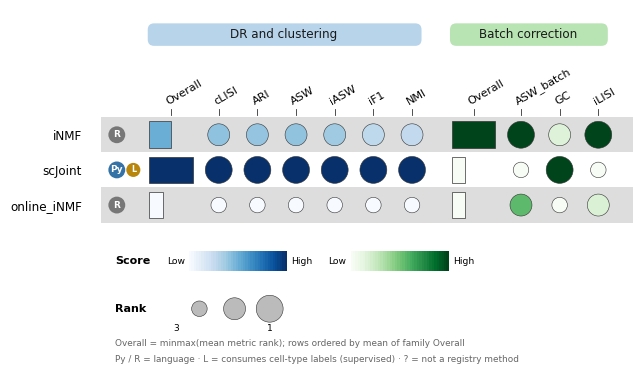

In [6]:
res.plot()

Each circle carries two encodings: its **size is the method's rank** in
that column (largest = rank 1) and its **colour is the metric's value**, min-max
scaled within the column (darker = higher). Columns are grouped by task family -
blues for DR & clustering, greens for batch correction - and each family is led
by an **Overall** rank column, where bar length and colour carry the same two
encodings.

## 3. Your own data

The same three calls - `scan`, `run_all`, `plot` - on a folder the package has
never seen. A dataset is a folder of flat files named by category:

In [7]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR DIAGONAL:
  rna.h5         <- the RNA cells
  atac.h5        <- the ATAC cells (gene activity); peak.h5 for peaks
  rna_cty.csv AND atac_cty.csv
                 <- ONE LABEL FILE PER MODALITY. The two cell sets are
                    disjoint, so they cannot share a single cty.csv.

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BAT

Each modality file is HDF5 with three datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

That is the **transpose** of the AnnData convention (`AnnData.X` is cells x
genes); the `mtb.io` writers below handle it, and `scan()` rejects a transposed
file at preflight rather than letting a method fail half an hour in. The label
CSV is a **single column** with one header line (typically `x`) and one label
per cell, in the same order as `matrix/barcodes` of the matching modality file.
For ATAC, check which representation a method wants - gene-activity scores or
peaks - because the wrong one runs to completion and returns a plausible but
wrong embedding. The shipped label files, as `evaluate` will read them - the
dict comes back in the benchmark's **cell-stacking order** (`cty`; `cty1, cty2,
...` numerically; `rna_cty` before `atac_cty`), so
`mtb.evaluate(embedding, labels=mtb.labels_for(DATASET))` scores a multi-file
dataset directly, with each cell's file of origin as its batch; a dict you
built in any other order must say so with `label_order=[...]`:

In [8]:
labels = mtb.labels_for(DATASET)            # {stem: path} in cell-stacking order - what the metrics are scored against
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")

{'rna_cty': 'rna_cty.csv', 'atac_cty': 'atac_cty.csv'}
"x"
"CD4 Naive"
"CD4 Naive"
"CD4 TCM"


Writing that layout from AnnData objects, executed here on a synthetic
example - sparse matrices stream without densifying, and the folder passes the
same file gate `scan` applies to the shipped datasets:

In [9]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
genes = [f"gene{i}" for i in range(40)]
rna  = ad.AnnData(X=rng.poisson(1.0, size=(120, 40)).astype(float)); rna.var_names = genes
atac = ad.AnnData(X=rng.poisson(0.5, size=(90, 40)).astype(float));  atac.var_names = genes   # gene-activity scores, DIFFERENT cells
rna.obs["celltype"]  = rng.choice(["T", "B", "NK"], 120)
atac.obs["celltype"] = rng.choice(["T", "B", "NK"], 90)

folder = os.path.join(tempfile.mkdtemp(), "MYDIAG"); os.makedirs(folder)
mtb.io.to_canonical(rna,  folder, modality="rna")        # -> rna.h5
mtb.io.to_canonical(atac, folder, modality="atac_gas")   # -> atac_gas.h5 (never a plain atac.h5, which methods read as PEAKS)
mtb.io.write_labels(rna.obs["celltype"],  os.path.join(folder, "rna_cty.csv"))
mtb.io.write_labels(atac.obs["celltype"], os.path.join(folder, "atac_cty.csv"))
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYDIAG", CATEGORY, data_path=os.path.dirname(folder))
print(f"{int(sc.files_ok.sum())} of {len(sc)} method variants pass the file gate (the rest want a peak matrix too)")

['atac_cty.csv', 'atac_gas.h5', 'rna.h5', 'rna_cty.csv']
10 of 14 method variants pass the file gate (the rest want a peak matrix too)


Now a real dataset the package has never seen: a 60% cell subsample of
`D28` under a new name, built with ordinary h5py/pandas code so the
per-file rule (matching files keep the same cell index) is visible.

In [10]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks two independent gates per method: `files_ok` - the folder
itself (files present, features x cells orientation, one label per cell) - and
`env_ok` - that method's conda environment exists on this machine. `runnable`
is both; `reason` says which failed and how to fix it. The file gate runs
anywhere, so a laptop without a single environment still tells you whether your
layout is right.

In [11]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D28"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_diagonal", frac=0.6)

sc = mtb.scan(f"MYDATA_diagonal", category=CATEGORY, data_path=DATA_ROOT)
print(f"files_ok {int(sc.files_ok.sum())}, env_ok {int(sc.env_ok.sum())}, runnable {int(sc.runnable.sum())} of {len(sc)} method variants")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

files_ok 14, env_ok 14, runnable 14 of 14 method variants


,method,modalities,files_ok,env_ok,runnable,reason
0,Conos,rna+atac_gas,True,True,True,
1,GLUE,rna+atac_peak,True,True,True,
2,MultiMAP,rna+atac_peak+atac_gas,True,True,True,
3,Portal,rna+atac_gas,True,True,True,
4,SCALEX,rna+atac_gas,True,True,True,
5,Seurat_v3,rna+atac_peak+atac_gas,True,True,True,


In [12]:
mine = mtb.run_all(f"MYDATA_diagonal", CATEGORY,
                   methods=['online_iNMF', 'iNMF', 'scJoint'],
                   out_dir=f"{DATA_ROOT}/out_diagonal",
                   data_path=DATA_ROOT)
mine.summary

[run_all] iNMF (diagonal/MYDATA_diagonal) ...


[run_all]   -> CHAIN_OK (40.1s) 0.4209


[run_all] online_iNMF (diagonal/MYDATA_diagonal) ...


[run_all]   -> CHAIN_OK (13.0s) 0.391


[run_all] scJoint (diagonal/MYDATA_diagonal) ...


[run_all]   -> CHAIN_OK (42.8s) 0.5634


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,iNMF,CHAIN_OK,40.1,embedding,"[6607, 20]",0,rna_cty.csv+atac_cty.csv,0.9865,file_of_origin,2,0.4209,0.5063,0.4703,0.4763,0.3968,0.9510,0.6846,0.7426,0.0064,None
1,online_iNMF,CHAIN_OK,13.0,embedding,"[6607, 20]",0,rna_cty.csv+atac_cty.csv,0.9982,file_of_origin,2,0.3910,0.4742,0.4603,0.4515,0.3648,0.9437,0.7806,0.7730,0.6694,None
2,scJoint,CHAIN_OK,42.8,embedding,"[6607, 64]",21,rna_cty.csv+atac_cty.csv,0.9996,file_of_origin,2,0.5634,0.6035,0.5292,0.5163,0.5212,0.9900,0.7225,0.8374,0.4971,None


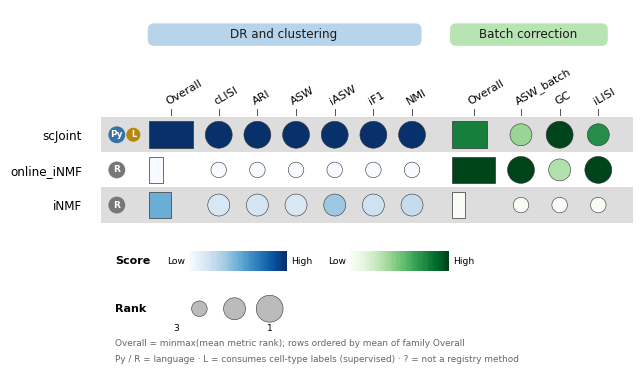

In [13]:
mine.plot()

All three reached CHAIN_OK with all nine metrics on this subsample when we ran them. For your real data the only work is producing the
canonical files - `mtb.io.export_dataset` from an AnnData / MuData, or
`to_canonical` + `write_labels` file by file as above - and these same three
calls do the rest.

## 4. Reading stored results

Section 2 ran three methods; the package ships the **full sweep** for `D28` -
every wired method at default settings, hours of compute - so the paper's
figures reproduce from stored results in seconds. `load_results` reads them
back as the tidy frame `mtb.plot.bubble` takes; `source="rerun"` selects the
package's own re-execution (the tables behind this notebook), `"published"`
the paper's tables, and every row says which it came from in its `source`
column.

/tmp/ipykernel_569948/2077197157.py:1: DegenerateRerunWarning: degenerate re-run row(s) - ARI < 0.01 where the published table scored > 0.2: Conos/D28 (rerun-0.2.1 ARI 0.0004 vs published 0.27). The re-run most likely failed silently (a collapsed embedding or a wrong label order), so the row says nothing about the method; drop it before ranking (df[df.method != 'Conos']) or compare with source='published'.
  long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")


12 methods, ['rerun-0.2.1']


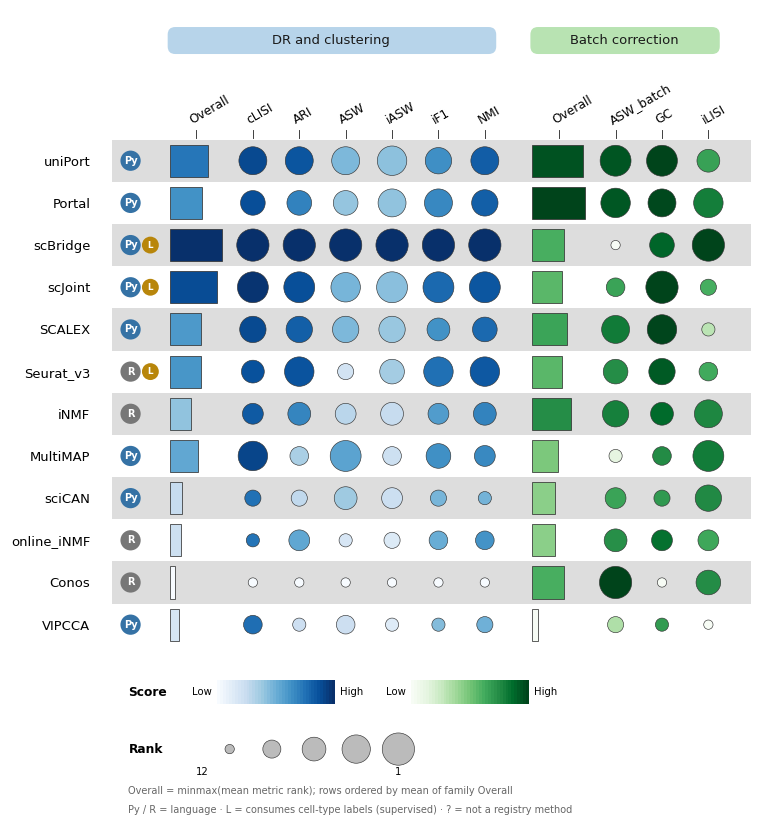

In [14]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

`run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` writes the
same `summary.csv` and `long.csv` for your own data; `mtb.load_batch(out_dir)`
reads them back. A single `mtb.evaluate` frame becomes the same seven-column
long frame with `mtb.to_long(metrics, method, dataset, category)`
(`source="user"`; `needs_labels=True` gives your own supervised method the
`L` badge), so `pd.concat([long, mine])` plots next to the stored sweep.

**Across datasets.** A summary needs every method to have results on every
dataset it averages over, or absence and performance blur into the same bar. Two
diagonal datasets therefore ship swept identically - `D28` and `D28s` (a 60% cell
subsample of `D28` under a new name) - and `require_complete=True` keeps only
the methods present on both, so the matrix is complete by construction. Each
bar is the **grand rank**: the min-max scaled mean rank across the datasets,
with length and colour both carrying it, and `Overall` is the same statistic
over the grand ranks. Both metric families appear because both datasets are multi-batch.

/tmp/ipykernel_569948/1307261061.py:1: DegenerateRerunWarning: degenerate re-run row(s) - ARI < 0.01 where the published table scored > 0.2: Conos/D28 (rerun-0.2.1 ARI 0.0004 vs published 0.27). The re-run most likely failed silently (a collapsed embedding or a wrong label order), so the row says nothing about the method; drop it before ranking (df[df.method != 'Conos']) or compare with source='published'.
  pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")


{'D28': 12, 'D28s': 12}


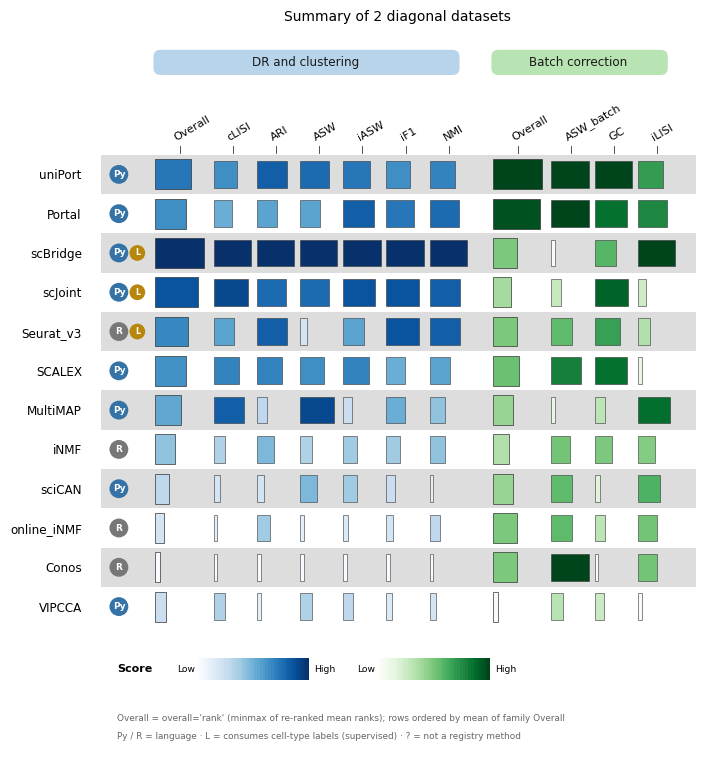

In [15]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 diagonal datasets")

**Published vs re-run.** The paper's own tables (`source="published"`)
and the package's re-runs can differ for a method - methods are stochastic and
the published sweep ran on other hardware - so cite the published numbers and
use the re-runs to check reproducibility; compare ranks, not decimals.
`results_coverage` says what exists for this dataset and where it came from:

In [16]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
published      14
rerun-0.2.1    12
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` inspects a folder and reports every runnable method - and for the rest,
the exact reason (missing file, missing environment, wrong layout). Nothing
executes. From the shell, `multibench scan DATASET --category CATEGORY` prints
the compact table (method, modalities, runnable, files_ok, env_ok,
runtime_tier, reason); `--columns all` or `--format csv|tsv|json` gives every
column, and `multibench run-all ... --dry-run` prints the plan plus the exact
command line per variant whose inputs resolve - the line to paste into a
scheduler job.

In [17]:
avail = mtb.scan(DATASET, category=CATEGORY)
avail[avail.runnable][["method", "modalities", "env", "output_kind",
                       "n_tunable", "needs_labels", "runtime_tier"]]

,method,modalities,env,output_kind,n_tunable,needs_labels,runtime_tier
0,Conos,rna+atac_gas,scmb_r,embedding,0,False,medium
1,GLUE,rna+atac_peak,glue,embedding,0,False,very_slow
2,MultiMAP,rna+atac_peak+atac_gas,scmb_torch,embedding,0,False,slow
3,Portal,rna+atac_gas,scmb_torch_v2,embedding,0,False,medium
4,SCALEX,rna+atac_gas,scmb_torch,embedding,0,False,slow
5,Seurat_v3,rna+atac_peak+atac_gas,scmb_seurat4b,embedding,0,True,slow
6,Seurat_v5,rna+atac_peak,scmb_seurat5,embedding,0,False,very_slow
7,VIPCCA,rna+atac_gas,scmb_vipcca27,embedding,0,False,medium
8,iNMF,rna+atac_gas,scmb_r,embedding,0,False,fast
9,online_iNMF,rna+atac_gas,scmb_r,embedding,0,False,fast


In [18]:
not_ok = avail[~avail.runnable][["method", "modalities", "files_ok", "env_ok", "reason"]]
not_ok.head(5) if len(not_ok) else "(everything in this category runs here)"


'(everything in this category runs here)'

### What each method exposes for tuning

`method_info(m)["supports"]` lists a method's variants with how many
hyperparameters each exposes on its command line; `mtb.params_for(m, CATEGORY,
modalities)` names them, `params={"Method": {"key": value}}` sets them in
`run_all` (`--param METHOD:KEY=VALUE` on the command line; `multibench params
METHOD` prints the same table for every variant). An empty `tunable` is honest: many upstream scripts hardcode their hyperparameters, and this
package never edits upstream code.

In [19]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,scJoint,rna+atac_gas,21,True,embedding
1,scBridge,(data_dir),13,True,embedding
2,uniPort,rna+atac_gas,1,False,embedding
3,Conos,rna+atac_gas,0,False,embedding
4,GLUE,rna+atac_peak,0,False,embedding
5,MultiMAP,rna+atac_peak+atac_gas,0,False,embedding
6,Portal,rna+atac_gas,0,False,embedding
7,SCALEX,rna+atac_gas,0,False,embedding
8,Seurat_v3,rna+atac_peak+atac_gas,0,True,embedding
9,Seurat_v5,rna+atac_peak,0,False,embedding


### What the registry knows about a method, and how to cite it

`method_info` carries the upstream reference, repository and version next to
the run metadata - `availability` says whether a public install can run it
(`'public'`, or `'benchmark-host-only'` for SPIRAL, the one method whose
script is not published), `needs_labels` is the any-variant flag (`supports[i]` has it
per variant), and `verbose=True` adds the long audit notes plus
`verification`, the recorded end-to-end run(s) behind `status='verified'`
(`{dataset, category, status, wall_s, ARI, baseline, verdict, note}`);
`mtb.cite` emits the benchmark entry plus one per method you ran.

In [20]:
info = mtb.method_info("online_iNMF", verbose=True)
{k: info[k] for k in ("id", "env", "availability", "needs_labels", "atac", "notes", "repo_url", "version", "reference", "verification")}

{'id': 'online_iNMF',
 'env': 'scmb_r',
 'availability': 'public',
 'needs_labels': False,
 'atac': 'gene_activity',
 'notes': 'Online (mini-batch) iterative NMF in rliger for scalable diagonal integration of scRNA-seq and scATAC-seq gene activity; R.',
 'repo_url': 'http://htmlpreview.github.io/?https://github.com/welch-lab/liger/blob/master/vignettes/UINMF_vignette.html',
 'version': '2.0.1',
 'reference': {'doi': '10.1038/s41587-021-00867-x',
  'title': 'Iterative single-cell multi-omic integration using online learning',
  'authors': 'Gao C, Liu J, Kriebel AR, Preissl S, Luo C, Castanon R, Sandoval J, Rivkin A, Nery JR, Behrens MM, Ecker JR, Ren B, Welch JD',
  'journal': 'Nature Biotechnology',
  'year': 2021},
 'verification': [{'dataset': 'D28',
   'category': 'diagonal',
   'status': 'CHAIN_OK',
   'wall_s': 99,
   'ARI': 0.3749,
   'baseline': 0.375,
   'verdict': 'OK',
   'note': None}]}

In [21]:
print(mtb.cite(['online_iNMF', 'iNMF', 'scJoint'], fmt="text"))   # fmt="bibtex" for the .bib entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Gao C, Liu J, Kriebel AR, Preissl S, Luo C, Castanon R, Sandoval J, Rivkin A, Nery JR, Behrens MM, Ecker JR, Ren B, Welch JD. Iterative single-cell multi-omic integration using online learning. Nature Biotechnology (2021). https://doi.org/10.1038/s41587-021-00867-x
Welch JD, Kozareva V, Ferreira A, Vanderburg C, Martin C, Macosko EZ. Single-Cell Multi-omic Integration Compares and Contrasts Features of Brain Cell Identity. Cell (2019). https://doi.org/10.1016/j.cell.2019.05.006
Lin Y, Wu TY, Wan S, Yang JYH, Wong WH, Wang YXR. scJoint integrates atlas-scale single-cell RNA-seq and ATAC-seq data with transfer learning. Nature Biotechnology (2022). https://doi.org/10.1038/s41587-021-01161-6


### The metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Batch metrics appear only when the dataset has real batches - their absence on a
single-batch dataset is correct, not missing data. `kBET` is opt-in
(`mtb.evaluate(..., slow_metrics=True)`) because it is much slower than the rest.

### Coverage of the paper

`scan()` answers "what runs on this dataset"; this answers how many of the
methods the paper benchmarks for **diagonal** the package wires at all.

In [22]:
PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}
IMPUTATION_ONLY = ['scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN']

paper = PAPER[CATEGORY]
wired = sorted(m for m in mtb.list_methods()
               if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
if missing:
    print("not wired here:", ", ".join(missing))
    imp = [m for m in missing if m in IMPUTATION_ONLY]
    if imp:
        print("  the paper evaluates these only via IMPUTATION, which is not wired:",
              ", ".join(imp))
else:
    print("full parity with the paper for this category")

paper benchmarks 14 methods for diagonal; this package wires 14
full parity with the paper for this category


## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `files_ok` False: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `env_ok` False | that method's conda env is not built | the reason carries the one-method `multibench env install ...` command |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` / `export_dataset` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |
| batch metrics scored against the wrong batches | `batch_source="file_of_origin"` is the label-file rule | `res.rescore(batch=my_vector)` re-scores the stored outputs without re-running |


## Next steps

- the other three tutorials: **vertical**, **mosaic**, **cross**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `mtb.recommend(CATEGORY, modalities=[...])` - stored-result ranking with coverage made explicit; methods wired for the category but absent from the chosen `source` appear with `grand_score` NaN rather than vanishing
- `mtb.sweep(...)` - one method over a range of one hyperparameter